<center>
<h1>Final Project - Peer Review Assignment</h1>
<h2>Stock Market Sentiment Analysis</h2>
<br>
<p>The stock market is influenced by a complex multitude of factors, including economic and geopolitical events, financial performance, and investor sentiment. This project aims to conduct a sentiment analysis of stock market news without the use of training labels in models to determine sentiments in news articles and identify notable sentiment trends. </p>
<p>Unsupervised learning promises valuable insights to investors, traders, and financial analysts, and the goal of this notebook is to uncover hidden patterns in textual data that may not be immediately apparent through traditional analysis, contributing to more informed decision-making in the complex world of stock market investments.</p>
<p>This notebook will approach stock market news sentiment analysis in the following steps: </p>
</center>
<ol>
    <li>Data collection </li>
    <li>Exploratory Data Analysis</li>
    <li>Text Preprocessing</li>
    <li>Feature Extraction</li>
    <li>Dimensionality Reduction</li>
    <li>Clustering</li>
    <li>Topic Modeling</li>
    <li>Validation</li>
 </ol>

<center><h2>Data Sources</h2></center>

<center>
<p>The dataset for this project is comprised of articles scraped from HTML and comes from a variety of news sources. The original list of article URLs was obtained from AlphaVantage, however the AlphaVantage News Sentiment API does not provide the actual text data that is used for sentiment analysis. HTML data was collected using Beautiful Soup and transformed into CSV for the purposes of this project.</p>
</center>

In [ ]:
'''
IMPORTS
'''
from collections import namedtuple, Counter
from gensim.models import KeyedVectors, Word2Vec
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.test.utils import datapath, get_tmpfile
import hdbscan
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import vader
from nltk.stem import PorterStemmer, WordNetLemmatizer
import numpy as np
import pandas as pd
from pathlib import Path  
import random
import re
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import NMF, TruncatedSVD, PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, ParameterGrid
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import normalize, LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.svm import SVC
import spacy
import string
from tabulate import tabulate
import time
import torch
from transformers import BertTokenizer, BertModel

<center><h2>Exploratory Data Analysis</h2></center>

#### Structure of the dataset

Records in the training dataset have the following structure:

* **id**: unique identifier
* **ticker** stock ticker
* **date** ISO format
* **title** article title
* **text**: article text content
* **source**: Benzinga , Business Insider, CNN, Forbes, Investors Business Daily, MarketWatch, Motley Fool, PR Newswire, Reuters, Stocknews.com or Zack's Commentary

In [14]:
'''
LOAD TRAIN AND TEST DATASETS
'''
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')
tickers = list(train['ticker'].unique())   

'''
GLOBALS
'''
color_list = ['#35193e', '#701f57', '#ad1759', '#e13342', '#f37651', '#f6b48f', '#221150', '#5f187f', '#982d80', '#d3436e', '#f8765c', '#febb81', '#46327e', '#365c8d', '#277f8e', '#1fa187', '#4ac16d', '#a0da39', '#e98d6b', '#e3685c', '#d14a61', '#b13c6c', '#8f3371', '#6c2b6d', '#7dba91', '#59a590', '#40908e', '#287a8c', '#1c6488', '#254b7f']

In [44]:
train.head(n=10)

,id,ticker,date,title,text,source
0,1,AAPL,20231005T072739,"'Rich Dad, Poor Dad' Author Robert Kiyosaki Sa...","Robert Kiyosaki, the author of the best-sellin...",Benzinga
1,2,AAPL,20231004T185420,Google Pixel Watch 2 Vs. Apple Watch Series 9:...,Alphabet Inc.’s GOOG GOOGL Google launched Pix...,Benzinga
2,3,AAPL,20231004T174231,"Apple CEO Tim Cook, Executives Sell Over $100M...",Records released on Tuesday showed several rec...,Benzinga
3,4,AAPL,20231004T124542,Apple Yields To Chinese Regulations: Developer...,Apple Inc. AAPL has ended its resistance to th...,Benzinga
4,5,AAPL,20231004T115134,Why Apple Shares Are Dipping Premarket Today -...,"Shares of tech giant Apple, Inc. AAPL pulled b...",Benzinga
5,6,AAPL,20231004T114814,Apple Accused Of 'Climate-Washing' By Chinese ...,"In a surprising turn of events, Apple Inc. AAP...",Benzinga
6,7,AAPL,20231004T100338,Apple's iPhone 15 Users Report Distorted Audio...,"Less than two weeks after its launch, the Appl...",Benzinga
7,8,AAPL,20231004T081827,Apple Loses A Bull: Analyst Lists 4 Reasons Fo...,Apple Inc. AAPL faced headwinds in the wake of...,Benzinga
8,9,AAPL,20231004T060858,Is Cupertino's Next Trick A USB-C-Powered Appl...,The discovery of a code reference within Apple...,Benzinga
9,10,AAPL,20231003T114438,"Watch Out Apple, Google: Samsung Is Reportedly...",Samsung Electronics Co SSNLF looks reportedly ...,Benzinga


<b>Number of entries:</b> 2655

In [46]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2655 entries, 0 to 2654
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2655 non-null   int64 
 1   ticker  2655 non-null   object
 2   date    2655 non-null   object
 3   title   2655 non-null   object
 4   text    2593 non-null   object
 5   source  2655 non-null   object
dtypes: int64(1), object(5)
memory usage: 124.6+ KB


In [12]:
print(train.isnull().sum())

id         0
ticker     0
date       0
title      0
text      62
source     0
label      0
dtype: int64


In [9]:
# Set copy of dataframe for EDA
df = train.copy(deep=True)
# Count nulls
print(df.isnull().sum())
# Drop rows with nulls
df.dropna(inplace=True)

id         0
ticker     0
date       0
title      0
text      62
source     0
label      0
dtype: int64


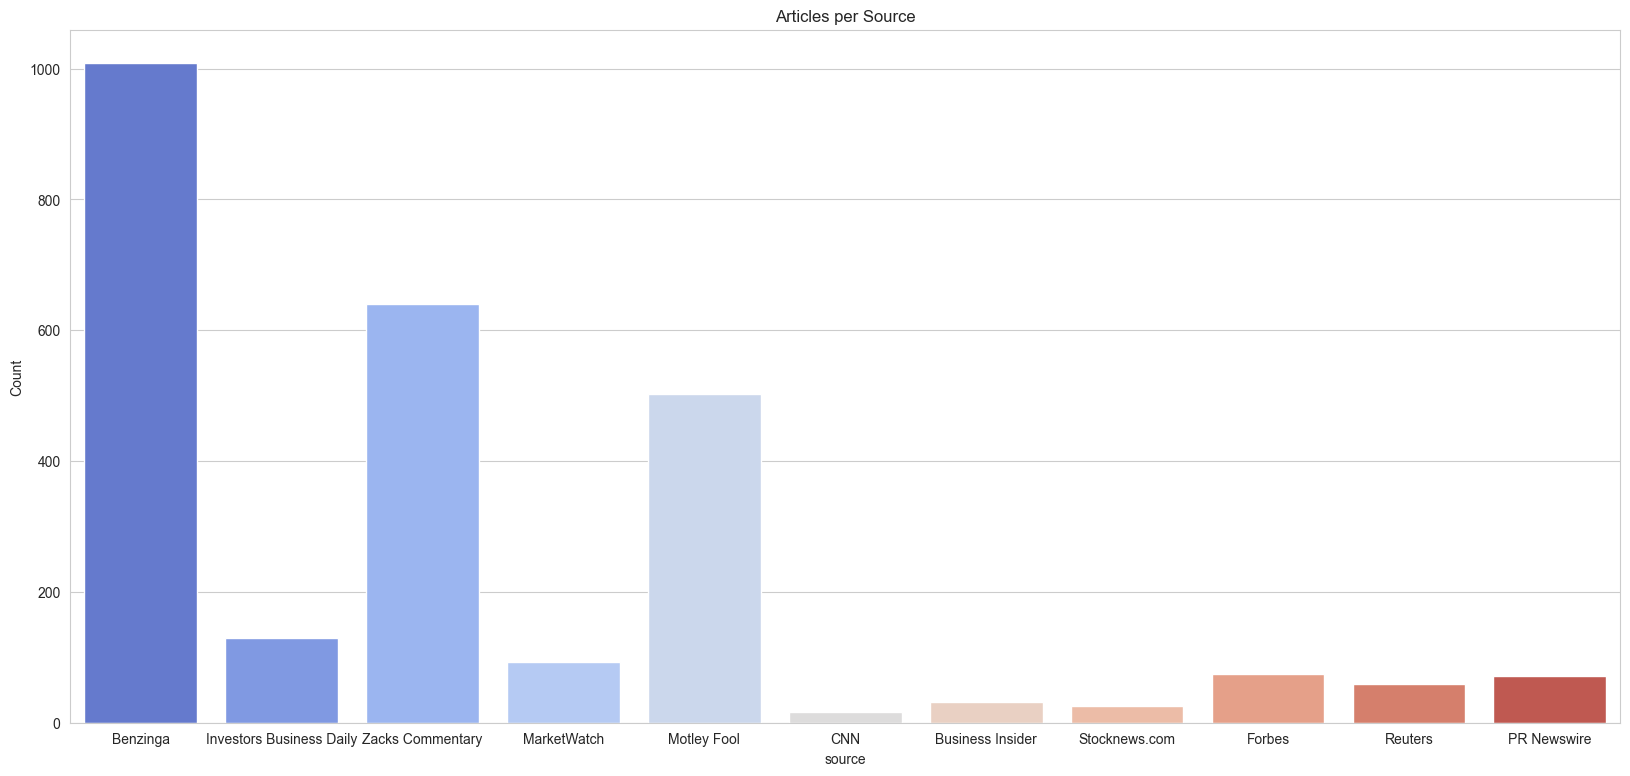

In [108]:
sns.set_style("whitegrid")
plt.figure(figsize=(20, 9))
sns.countplot(data=train, x='source',palette='coolwarm')
plt.title('Articles per Source')
plt.ylabel('Count')
plt.show()

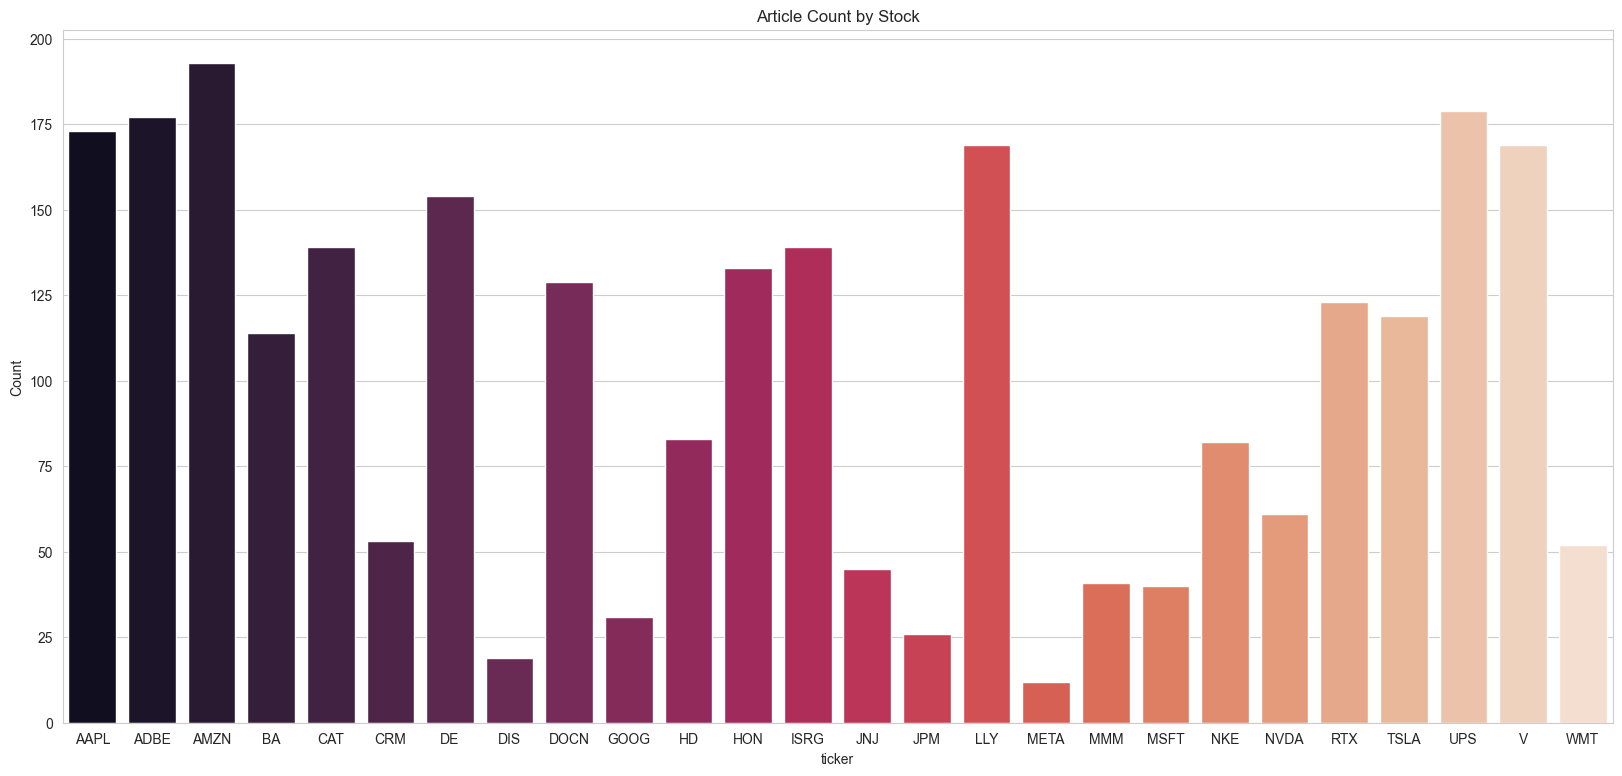

In [5]:
sns.set_style("whitegrid")
plt.figure(figsize=(20, 9))
sns.countplot(data=train, x='ticker',palette='rocket')
plt.title('Article Count by Stock')
plt.ylabel('Count')
plt.show()

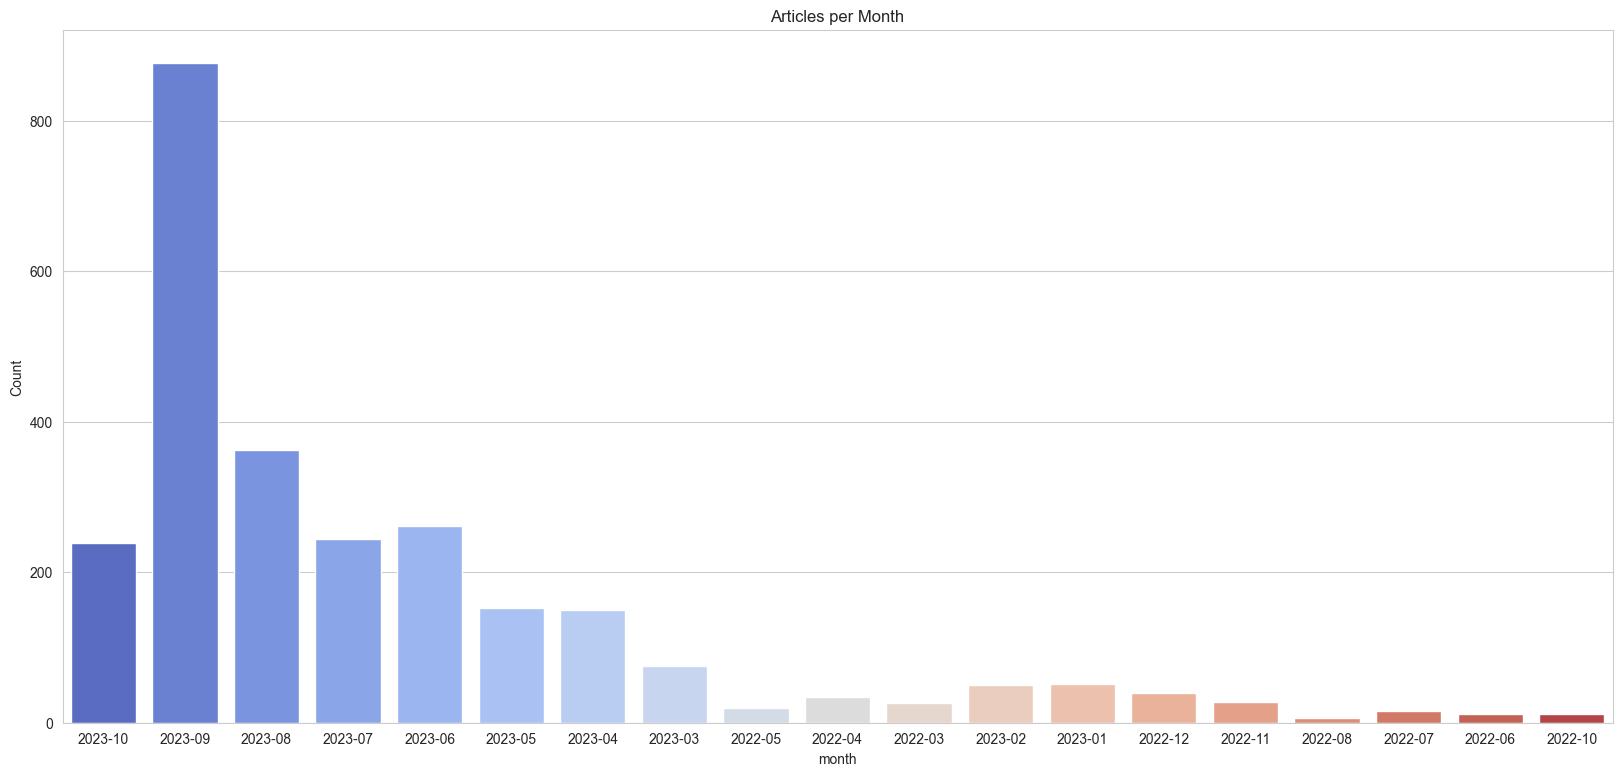

In [11]:
df['datetime'] = pd.to_datetime(df['date'])
df['month'] = df['datetime'].dt.to_period('M')
sns.set_style("whitegrid")
plt.figure(figsize=(20, 9))
sns.countplot(data=df, x='month',palette='coolwarm')
plt.title('Articles per Month')
plt.ylabel('Count')
plt.show()

<center><h3>Basic Text Analysis</h3></center>

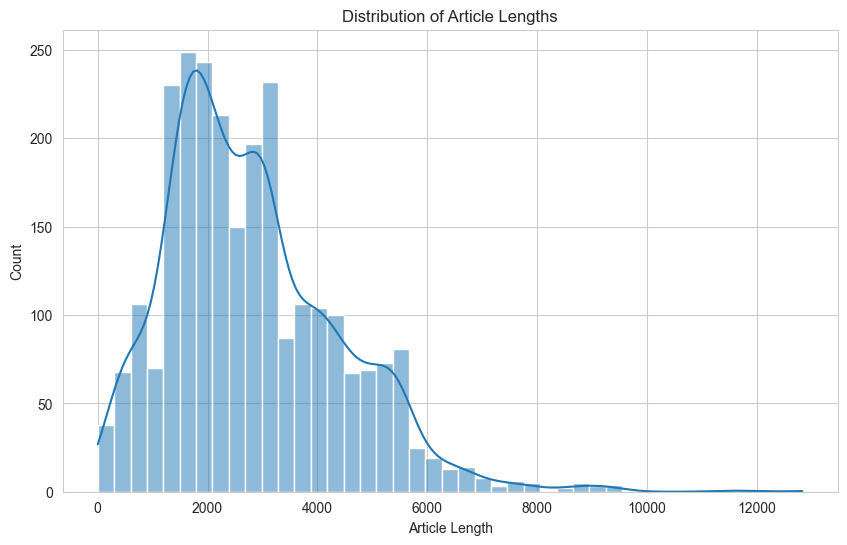

In [93]:
article_lengths = [len(article) for article in df['text']]
plt.figure(figsize=(10, 6))
sns.histplot(pd.DataFrame({'Article Length': article_lengths}), x='Article Length', kde=True)
plt.title('Distribution of Article Lengths')
plt.show()


<center><b>Extracting Word Features</b></center>
 <br>
<center>This notebook compares <code>TfidfVectorizer</code> and <code>Bert</code> for purposes of transforming article text into numerical feature vectors.</center>


<center><b>Frequent Terms</b></center>


In [16]:
df = train.copy(deep=True)
df.dropna(inplace=True)

tfidf = TfidfVectorizer(
    sublinear_tf=True,
    min_df=5,
    norm='l2',
    encoding='latin-1',
    ngram_range=(1, 2),
    stop_words='english'
)

feature_vectors = tfidf.fit_transform(df['text']).toarray()

freq_terms      = {}

for ticker in tickers:
    features_chi2   = chi2(feature_vectors, df['ticker'] == ticker)
    indices         = np.argsort(features_chi2[0])
    feature_names   = np.array(tfidf.get_feature_names_out())[indices]
    terms           = [v for v in feature_names if len(v.split(' ')) < 3 and ticker.lower() not in v]
    freq_terms[ticker.lower()] = ', '.join(terms[-30:])

def view_frequent_terms(ticker, freq_terms):
    print(f'{ticker}:\n')
    print(freq_terms[ticker])
    print('')

In [95]:
view_frequent_terms('aapl', freq_terms)
view_frequent_terms('msft', freq_terms)
view_frequent_terms('ba', freq_terms)
view_frequent_terms('mmm', freq_terms)
view_frequent_terms('jpm', freq_terms)
view_frequent_terms('lly', freq_terms)

aapl:

event, 15 plus, smartphone, tim, wonderlust event, watch ultra, airpods, consumer tech, new iphone, benzinga consumer, tech coverage, pro iphone, wonderlust, tim cook, titanium, cook, apple iphone, watch series, 15 series, iphone 14, series, usb, apple stock, iphones, pro max, apple watch, 15 pro, iphone 15, iphone, apple

msft:

openai 2019, billion chatgpt, game, games, cma, chat, altman, microsoft corporation, openai service, azure openai, pass, chatgpt, microsoft shares, 49 stake, windows, azure, bing, blizzard, activision blizzard, activision, microsoft stock, bing chat, 365, openai, microsoft cloud, nuclear, copilot, xbox, microsoft 365, microsoft

ba:

aft, aft pressure, boeing months, stance boeing, boeing benzinga, holes, bulkhead, boeing options, spr, max jets, 787 dreamliner, airlines, airplane, trades boeing, boeing stock, max, planes, dreamliner, airbus, boeing 737, boeing company, 787, aerosystems, spirit aerosystems, aircraft, jets, spirit, 737 max, 737, boeing

m

<center><b>Named Entity Recognition</b></center>
<br>
<center>NER can help pinpoint which part of the article a sentiment is referring to by identifying named entities. It is important to check NER results for irrelevant details.</center>

In [100]:
# Load the English NER model
nlp = spacy.load('en_core_web_sm')

def extract_entities_from_article(article):
    """Extract named entities from a single article and return them as a list."""
    doc = nlp(article)
    return [ent.text for ent in doc.ents]

def extract_common_entities(articles, top_n=10):
    """Extract the top_n common named entities from a list of articles."""
    all_entities = []

    # Extract entities from each article
    for article in articles:
        all_entities.extend(extract_entities_from_article(article))

    # Get the most common entities
    entity_freq = Counter(all_entities)
    common_entities = entity_freq.most_common(top_n)

    return common_entities

def articles_by_ticker(ticker):
    articles = df[df['ticker'] == ticker]
    return articles['text']



In [105]:
tesla_articles  = articles_by_ticker('TSLA')
extract_common_entities(tesla_articles)

[('Tesla', 868),
 ('EV', 143),
 ('Musk', 88),
 ('Cybertruck', 76),
 ('China', 68),
 ('third-quarter', 63),
 ('U.S.', 55),
 ('Elon Musk', 54),
 ('Monday', 54),
 ('Q3', 53)]

In [104]:
google_articles = articles_by_ticker('GOOG')
extract_common_entities(google_articles)

[('Google', 291),
 ('Apple', 112),
 ('AI', 92),
 ('Pixel', 72),
 ('Microsoft', 70),
 ('8', 49),
 ('Nadella', 44),
 ('Bing', 38),
 ('2', 37),
 ('Bard', 30)]

In [106]:
ups_articles = articles_by_ticker('UPS')
extract_common_entities(ups_articles)

[('United Parcel Service', 429),
 ('UPS', 365),
 ('Teamsters', 188),
 ('Zacks Rank', 137),
 ('U.S.', 119),
 ('FedEx', 109),
 ('1', 99),
 ('today', 85),
 ('PEG', 80),
 ('Transportation', 68)]

In [107]:
cat_articles = articles_by_ticker('CAT')
extract_common_entities(cat_articles)

[('Caterpillar', 746),
 ('CAT', 270),
 ('Zacks Rank', 136),
 ('1', 115),
 ('EPS', 86),
 ('today', 78),
 ('the last 30 days', 69),
 ('three', 65),
 ('CAT Quick', 62),
 ('the past month', 57)]

<center><h3>Text Data Preprocessing</h3></center>
<br>
<center>The first step in any unsupervised sentiment analysis task is preprocessing the text data. This involves tokenization, removing stop words, stemming or lemmatization, and other techniques to convert raw text into a format suitable for analysis.</center>
<br>
<center>
One key question for data preprocessing is how to handle numbers in text since removing numbers could cause a loss of critical sentiment information.  For example, "Company X profits increased by 25%" conveys a completely different sentiment than "Company X profits decreased by 25%." At the same time, including numbers might lead to overfitting. Also, it will be important to pay attention to how numerical values are tokenized in order to determine how this might impact the model's interpretation of sentiment.
</center>
<br>
<center>
Ultimately there is no one-size-fits-all solution to this question. To deal with this problem, we will run some experiments during EDA to pick the best method for the task fo unsupervised stock market sentiment analysis.
</center>

In [17]:
def remove_unicode(s):
    try:
        s = s.replace("\xa0"," ").replace('’', "'")
        return ''.join(c for c in s if 32 <= ord(c) <= 126 or c in ['\t', '\n', '\r'])
    except Exception as e:
        return s
    
def convert_to_lowercase(s):
    try:
        return s.lower()
    except Exception as e:
        return s
    
def remove_urls(s):
    try:
        return re.sub(r'http\S+|www\S+', '', s)
    except Exception as e:
        return s
    
def remove_numbers(s):
    try:
        return re.sub(r'\d+', '', s)
    except Exception as e:
        return s
    
def remove_punctuation(s):
    try:
        return s.translate(str.maketrans('', '', string.punctuation))
    except Exception as e:
        return s
    
def tokenize(s):
    try:
        # Tokenize
        tokens = word_tokenize(s)
        # Remove stopwords
        tokens = [word for word in tokens if word not in stopwords.words('english')]
        # Stemming (Could also use Lemmatization here)
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(word) for word in tokens]
        # Join tokens back to string
        s = ' '.join(tokens)
        return s
    except Exception as e:
        return s
    
# HTML tags already removed using Beautiful Soup
def preprocess_text(text):
    text = convert_to_lowercase(text) 
    text = remove_urls(text)
    text = remove_unicode(text)
    return text

def tokenize_text(text):
    text = remove_numbers(text)
    text = remove_punctuation(text)
    text = tokenize(text)
    return text

<center>Original text:</center>
<br>
<pre>"Apple Inc AAPL shares are trading lower by 2.5% to $171.74 Tuesday afternoon. Apple shares are falling\xa0amid overall market weakness as traders and investors weigh concerns about future rate hikes following\xa0last Wednesday's FOMC statement\xa0and lower-than-expected initial jobless claims data. Why It Matters Apple's products, such as iPhones and MacBooks, are often purchased through financing options like loans or credit cards. Higher interest rates can increase the cost of borrowing for consumers, potentially reducing the affordability of Apple products. This could lead to lower sales and revenue for the company. See Also:\xa0Google Podcasts To Sunset in 2024, YouTube Music Rises As Podcasting Hub Apple also\xa0holds significant cash reserves and also uses debt financing for various purposes. When interest rates rise, it becomes more expensive for Apple to finance debt, which can lead to higher interest expenses. This, in turn, can impact Apple's bottom line by reducing its net income. What's Going On?  The Federal Reserve last week maintained the federal funds rate within the 5.25% to 5.5% range at its September meeting\xa0in a unanimous move. The September dot plot reveals the median preference for the fed funds rate at the close of 2023 remains unwavering at 5.6%. This figure mirrors projections made back in June, hinting at the possibility of one more rate hike during either of the last two meetings this year...Read More According to data from\xa0Benzinga Pro, AAPL has a 52-week high of $198.23 and a 52-week low of $124.17."
</pre>

<center>Tokenization with numbers:</center>
<br>
<pre>'appl inc aapl share trade lower 25 17174 tuesday afternoon appl share fall amid overal market weak trader investor weigh concern futur rate hike follow last wednesday fomc statement lowerthanexpect initi jobless claim data matter appl product iphon macbook often purchas financ option like loan credit card higher interest rate increas cost borrow consum potenti reduc afford appl product could lead lower sale revenu compani see also googl podcast sunset 2024 youtub music rise podcast hub appl also hold signific cash reserv also use debt financ variou purpos interest rate rise becom expens appl financ debt lead higher interest expens turn impact appl bottom line reduc net incom what go feder reserv last week maintain feder fund rate within 525 55 rang septemb meet unanim move septemb dot plot reveal median prefer fed fund rate close 2023 remain unwav 56 figur mirror project made back june hint possibl one rate hike either last two meet yearread accord data benzinga pro aapl 52week high 19823 52week low 12417'</pre>

<center>Without tokenization:</center>
<br>
<pre>"apple inc aapl shares are trading lower by 2.5% to $171.74 tuesday afternoon. apple shares are falling amid overall market weakness as traders and investors weigh concerns about future rate hikes following last wednesday's fomc statement and lower-than-expected initial jobless claims data. why it matters apple's products, such as iphones and macbooks, are often purchased through financing options like loans or credit cards. higher interest rates can increase the cost of borrowing for consumers, potentially reducing the affordability of apple products. this could lead to lower sales and revenue for the company. see also: google podcasts to sunset in 2024, youtube music rises as podcasting hub apple also holds significant cash reserves and also uses debt financing for various purposes. when interest rates rise, it becomes more expensive for apple to finance debt, which can lead to higher interest expenses. this, in turn, can impact apple's bottom line by reducing its net income. what's going on?  the federal reserve last week maintained the federal funds rate within the 5.25% to 5.5% range at its september meeting in a unanimous move. the september dot plot reveals the median preference for the fed funds rate at the close of 2023 remains unwavering at 5.6%. this figure mirrors projections made back in june, hinting at the possibility of one more rate hike during either of the last two meetings this year...read more according to data from benzinga pro, aapl has a 52-week high of $198.23 and a 52-week low of $124.17."</pre>

<center>Final results from preprocessing:</center>
<br>
<pre>'appl inc aapl share trade lower tuesday afternoon appl share fall amid overal market weak trader investor weigh concern futur rate hike follow last wednesday fomc statement lowerthanexpect initi jobless claim data matter appl product iphon macbook often purchas financ option like loan credit card higher interest rate increas cost borrow consum potenti reduc afford appl product could lead lower sale revenu compani see also googl podcast sunset youtub music rise podcast hub appl also hold signific cash reserv also use debt financ variou purpos interest rate rise becom expens appl financ debt lead higher interest expens turn impact appl bottom line reduc net incom what go feder reserv last week maintain feder fund rate within rang septemb meet unanim move septemb dot plot reveal median prefer fed fund rate close remain unwav figur mirror project made back june hint possibl one rate hike either last two meet yearread accord data benzinga pro aapl week high week low'
</pre>

In [18]:
'''
Based on test results let's go ahead and apply all preprocessing steps to article text
since tokenization without removing numbers produces some unhelpful meanings
'''
df['preprocessed_text'] = df['text'].apply(preprocess_text)
df['tokenized_text']    = df['preprocessed_text'].apply(tokenize_text)

<center><h3>Feature Extraction</h3></center>

In [19]:
class BERTFeatureExtractor:
    def __init__(self, model_name='bert-base-uncased'):
        self.device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = BertTokenizer.from_pretrained(model_name)
        self.model     = BertModel.from_pretrained(model_name).to(self.device)
        self.model.eval()

    def extract_features(self, text):
        inputs = self.tokenizer(
            text, 
            return_tensors="pt", 
            max_length=512, 
            truncation=True, 
            padding='max_length'
        ).to(self.device)
        with torch.no_grad():
            outputs = self.model(**inputs)
        return outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    
    def reduce_features(self, features,n_components=2):
        pca = PCA(n_components=n_components)
        return pca.fit_transform(features)

bert_extractor = BERTFeatureExtractor()
bert_features  = [bert_extractor.extract_features(text) for text in df['tokenized_text']]
bert_reduced   = bert_extractor.reduce_features(bert_features)

In [453]:
class TFIDFFeatureExtractor:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
    
    def extract_features(self, text, training=True):
        if training:
            return np.asarray(self.vectorizer.fit_transform(text).todense())
        else:
            return np.asarray(self.vectorizer.transform(text).todense())
    
    def reduce_features(self, features, n_components=2):
        pca = PCA(n_components=n_components)
        return pca.fit_transform(features)

tfidf_extractor = TFIDFFeatureExtractor()
tfidf_features  = tfidf_extractor.extract_features(df['tokenized_text'])
tfidf_reduced   = tfidf_extractor.reduce_features(tfidf_features)

In [455]:
def set_classifier_results(self, clf, test_case, X_train, y_train, X_test, y_test):
        clf.fit(X_train, y_train)
        y_hat = clf.predict(X_test)
        self.cr[test_case] = classification_report(y_test, y_hat)
        self.cm[test_case] = confusion_matrix(y_test, y_hat)

test['preprocessed_text'] = test['text'].apply(preprocess_text)
test['tokenized_text']    = test['preprocessed_text'].apply(tokenize_text)
test_tfidf_features  = tfidf_extractor.extract_features(test['tokenized_text'], False)
test_tfidf_reduced   = tfidf_extractor.reduce_features(test_tfidf_features)
test_bert_features  = [bert_extractor.extract_features(text) for text in test['tokenized_text']]
test_bert_reduced   = bert_extractor.reduce_features(test_bert_features)

<center><h3>Dimensionality Reduction</h3></center>

In [224]:
def plot_2d(projected_2d_features, colors, title):   
    df_2d            = pd.DataFrame(projected_2d_features, columns=['x', 'y'])
    df_2d['ticker']  = df['ticker']
    plt.figure(figsize=(10, 8))
    for index,ticker in enumerate(tickers):
        points = df_2d[df_2d['ticker'] == ticker] 
        plt.scatter(points['x'], points['y'], s=30, c=colors[index], label=ticker)
    plt.legend()
    plt.title(title)

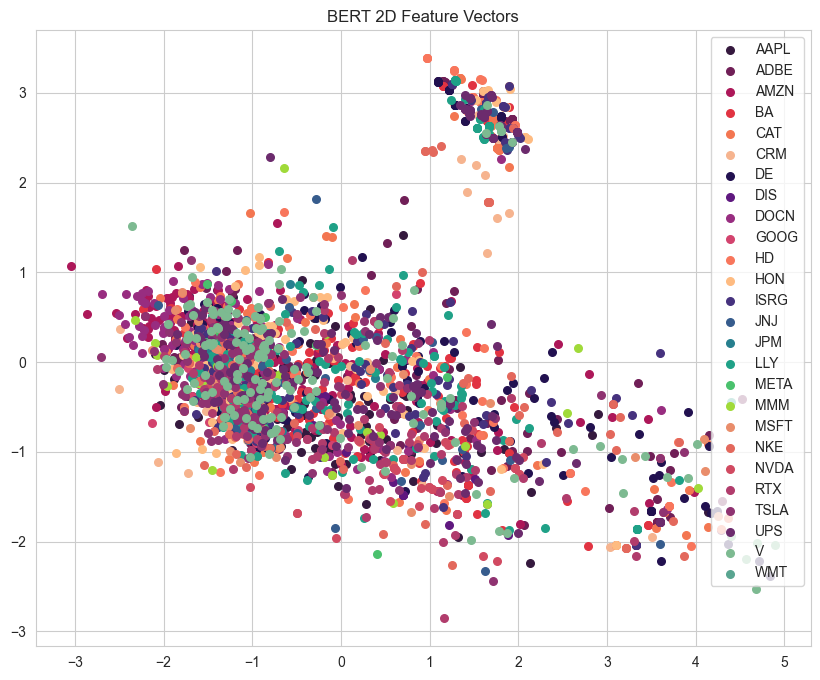

In [225]:
plot_2d(bert_reduced, color_list, 'BERT 2D Feature Vectors')

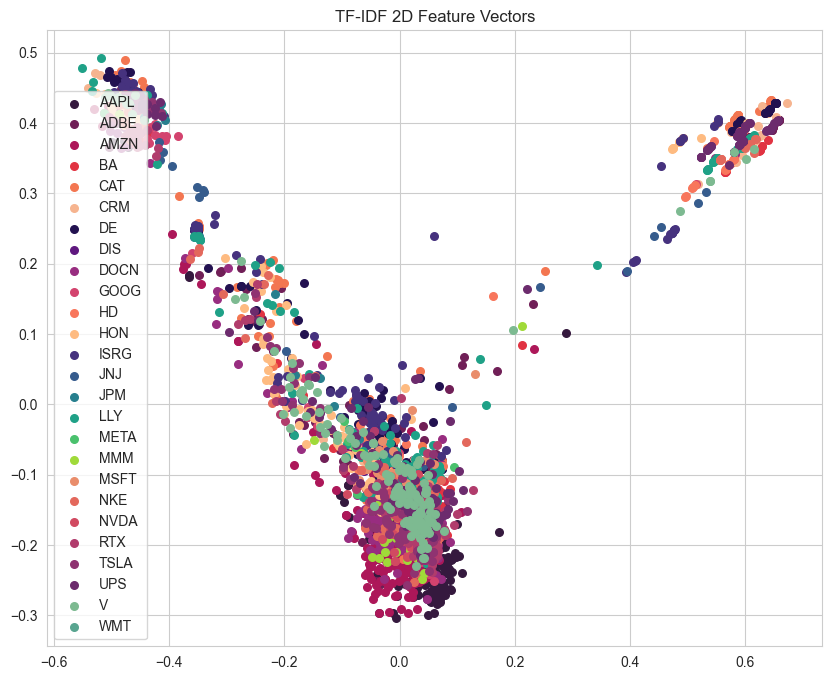

In [226]:
plot_2d(tfidf_reduced, color_list, 'TF-IDF 2D Feature Vectors')

<center><h1>Data Models</h1></center>

<center><h2>1) KMeans</h2></center>

In [465]:
class KMeansModel:
    def __init__(self, data, k=3):
        self.k      = k
        self.kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        self.df     = data.copy(deep=True)
        self.sia    = vader.SentimentIntensityAnalyzer()
        self.index_to_sentiment = {
            0: "Bullish",
            1: "Neutral",
            2: "Bearish"
        }
        
    def predict(self, X, feature='tokenized_text'):
        cluster_labels        = self.kmeans.fit_predict(X)
        cluster_sentiments    = self.assign_sentiments(cluster_labels, feature)
        sentiment_predictions = [cluster_sentiments[label] for label in cluster_labels]
        return sentiment_predictions
  
    def assign_sentiments(self, clusters, feature='tokenized_text'):
        self.df['cluster'] = clusters
        gk                 = self.df.groupby('cluster')
        cluster_scores     = []
        cluster_sentiments = {}
        
        # calculate mean polarity score for cluster
        for i in range(self.k):
            scores = []
            
            for index, row in gk.get_group(i).iterrows():
                score = self.sia.polarity_scores(row[feature])
                scores.append(score['compound'])
                
            cluster_scores.append({'cluster': i, 'mean': np.mean(scores)})

        # iterate over mean scores in descending order, i.e. assign positive sentiment to highest score, etc
        for index, cluster_score in enumerate(sorted(cluster_scores, key=lambda x: x['mean'], reverse=True)):
            cluster_sentiments[cluster_score['cluster']] = self.index_to_sentiment[index]

        return cluster_sentiments
    
kmeans_model       = KMeansModel(df, 3)
kmeans_predictions = kmeans_model.predict(bert_features)
kmeans_accuracy    = accuracy_score(df['label'], kmeans_predictions)

<center><h3>KMeans Results</h3></center>

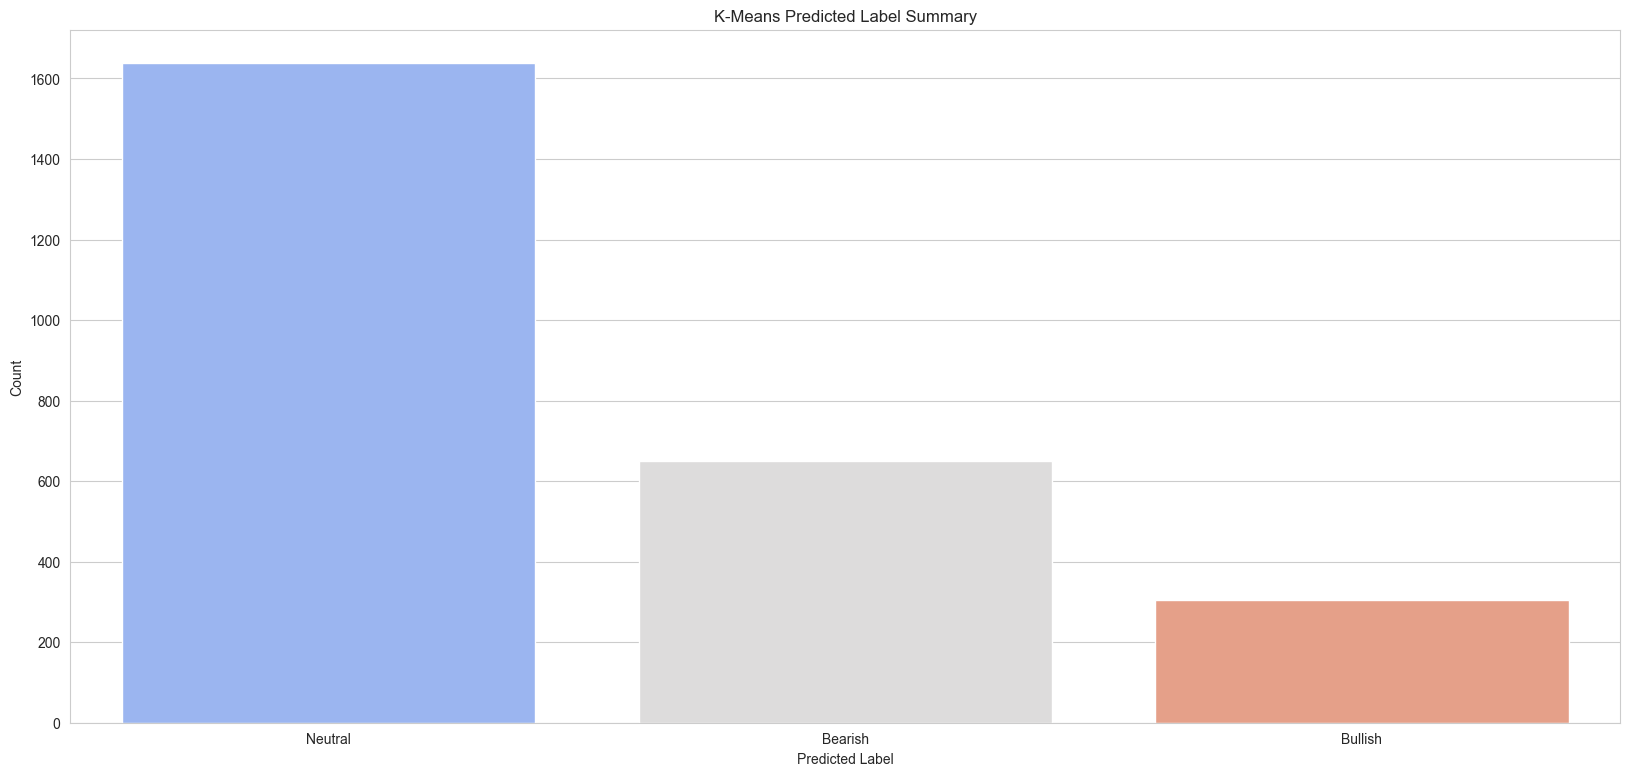

In [267]:
kmeans_results                    = df.copy(deep=True)
kmeans_results['Predicted Label'] = kmeans_predictions
plot_count(kmeans_results, 'Predicted Label', 'K-Means Predicted Label Summary')

In [265]:
print(classification_report(kmeans_results.label, kmeans_predictions))

              precision    recall  f1-score   support

     Bearish       0.02      0.60      0.04        20
     Bullish       0.00      0.00      0.00       213
     Neutral       0.90      0.62      0.73      2360

    accuracy                           0.57      2593
   macro avg       0.30      0.41      0.26      2593
weighted avg       0.82      0.57      0.67      2593



<Axes: >

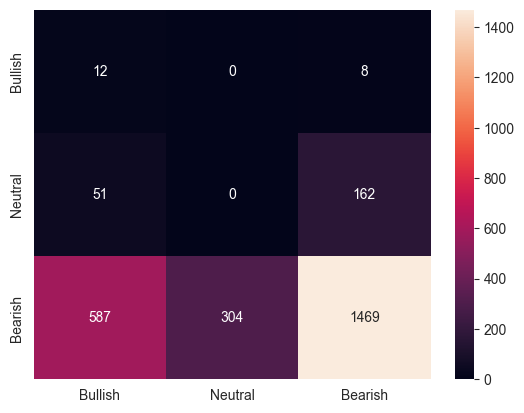

In [266]:
sns.heatmap(
    confusion_matrix(kmeans_results.label, kmeans_predictions), 
    annot=True, 
    fmt='d',
    xticklabels=['Bullish', 'Neutral', 'Bearish'],
    yticklabels=['Bullish', 'Neutral', 'Bearish']
)

In [264]:
kmeans_accuracy

0.5711531045121481

<center><h2>2) DBSCAN</h2></center>

In [332]:
class DBSCANModel:
    def __init__(self, data, X):
        self.X  = X
        self.df = data.copy(deep=True)
        self.set_distance_matrix()
        self.sentiment_index = {
            -1: "Bullish",
            0: "Neutral",
            1: "Bearish"
        }
        
    # Ensure values are in the range [-1, 1]
    def set_distance_matrix(self):
        similarity_matrix = cosine_similarity(self.X)
        similarity_matrix = np.clip(similarity_matrix, -1, 1)
        self.distance_matrix = 1 - similarity_matrix
          
    
    def predict(self):
        db = DBSCAN(eps=0.05, min_samples=3, metric='precomputed').fit(self.distance_matrix)
        sentiment_predictions = [self.sentiment_index[label] for label in db.labels_]
        return sentiment_predictions

dbscan_model       = DBSCANModel(df, bert_features)
dbscan_predictions = dbscan_model.predict()
dbscan_accuracy    = accuracy_score(df['label'], dbscan_predictions)
print("dbscan_accuracy: ", dbscan_accuracy)

dbscan_accuracy:  0.895102198225993


<center><h3>DBSCAN Results</h3></center>

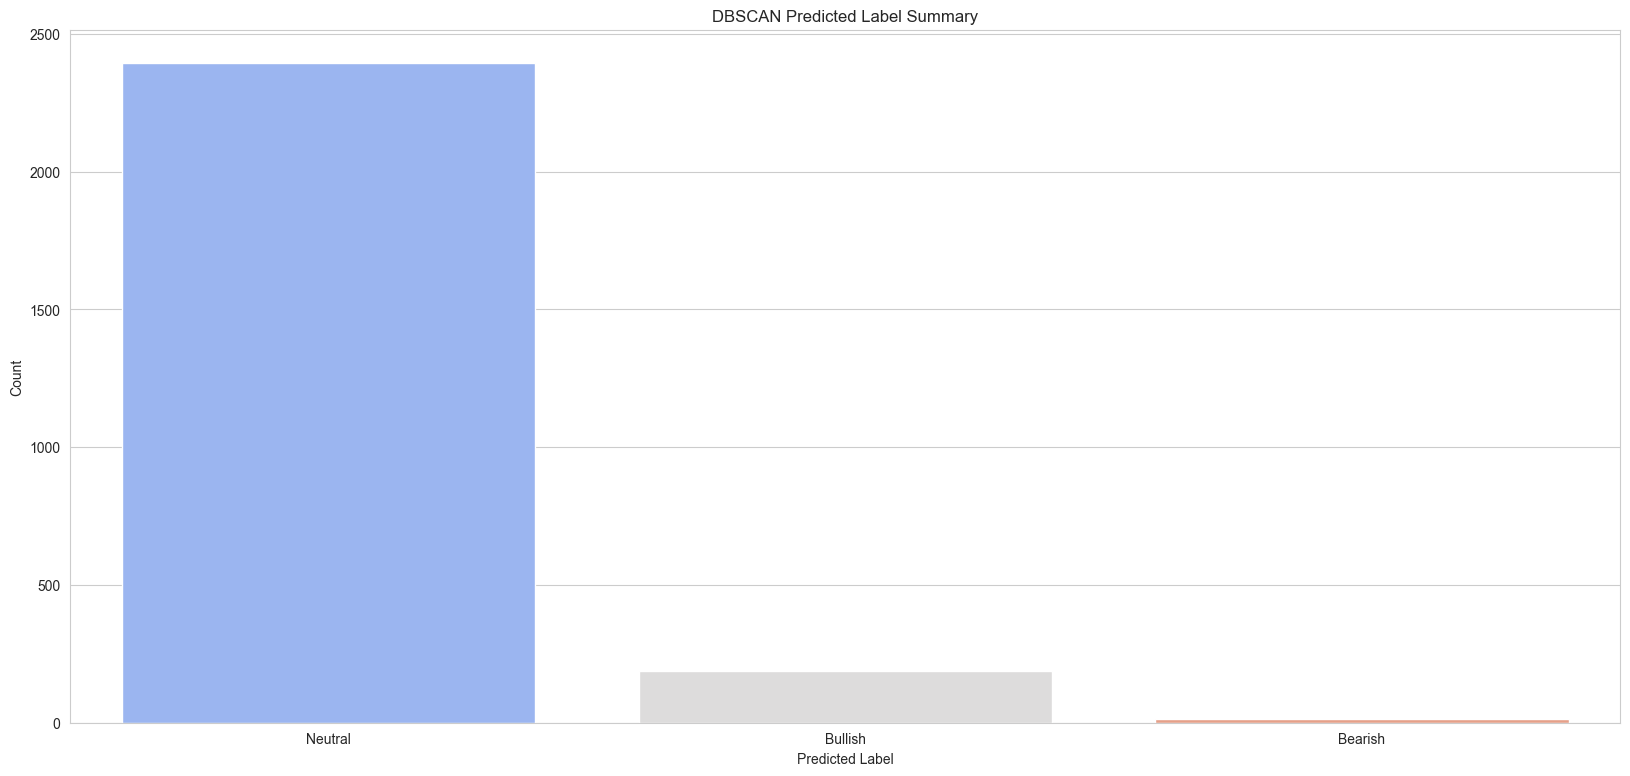

In [284]:
dbscan_results                    = df.copy(deep=True)
dbscan_results['Predicted Label'] = dbscan_predictions
plot_count(dbscan_results, 'Predicted Label', 'DBSCAN Predicted Label Summary')

In [285]:
print(classification_report(dbscan_results.label, dbscan_predictions))

              precision    recall  f1-score   support

     Bearish       0.00      0.00      0.00        20
     Bullish       0.06      0.06      0.06       213
     Neutral       0.91      0.92      0.92      2360

    accuracy                           0.85      2593
   macro avg       0.33      0.33      0.33      2593
weighted avg       0.83      0.85      0.84      2593



<Axes: >

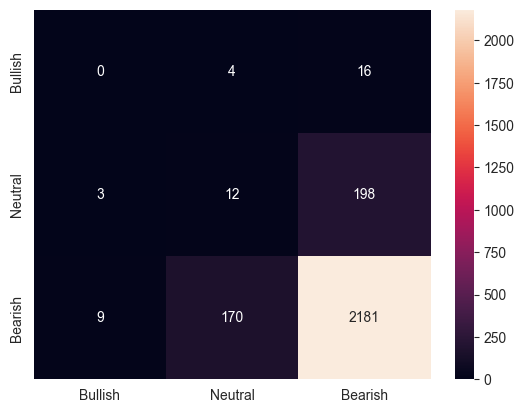

In [286]:
sns.heatmap(
    confusion_matrix(dbscan_results.label, dbscan_predictions), 
    annot=True, 
    fmt='d',
    xticklabels=['Bullish', 'Neutral', 'Bearish'],
    yticklabels=['Bullish', 'Neutral', 'Bearish']
)

<center><h2>Diving Deeper into the Results</h2></center>
<br>
<center>The following section randomly compares the sentiments predicted by the models with AlphaVantage labels and offers a bit of context into some of the discrepancies between the models and the API. The last three outputs of the section in particular seem to indicate that these API labels are not a perfect metric for measuring model outcomes since there is no discernible reason why the sentiment should be bearish instead of neutral.</center>

In [ ]:
class ClusteringResults:
    def __init__(self, data, dbscan_predictions, kmeans_predictions):
        self.dbscan   = dbscan_predictions
        self.kmeans   = kmeans_predictions
        self.articles = list(data.text)
        self.titles   = list(data.title)
        self.labels   = list(data.label)
        self.sources  = list(data.source)
    
    def inspect_prediction(self, i, show_full_output=True):
        if show_full_output:
            output=f"""{self.titles[i]} ({self.sources[i]})
            \n{self.articles[i]}
            \nKMeans Prediction: {self.kmeans[i]}\nDBSCAN Prediction: {self.dbscan[i]}\nAPI Label:         {self.labels[i]}
            """
            print(output)
        else:
            output=f"""{self.titles[i]} ({self.sources[i]})
            \nKMeans Prediction: {self.kmeans[i]}\nDBSCAN Prediction: {self.dbscan[i]}\nAPI Label:         {self.labels[i]}\n
            """
            print(output)
        

clustering_results = ClusteringResults(df, optimized_dbscan_predictions, kmeans_predictions)

In [429]:
def get_random_integers(n, a, b):
    return [random.randint(a, b) for _ in range(n)]

for i in get_random_integers(14, 0, len(list(df.text))):
    clustering_results.inspect_prediction(i, False)

Analyzing Tesla's  ( TSLA )  Potential Post Q3 Delivery Estimate Miss (Zacks Commentary)
            
KMeans Prediction: Neutral
DBSCAN Prediction: Neutral
API Label:         Neutral

            
$1000 Invested In This Stock 15 Years Ago Would Be Worth $8,800 Today - Adobe  ( NASDAQ:ADBE )  (Benzinga)
            
KMeans Prediction: Bearish
DBSCAN Prediction: Neutral
API Label:         Neutral

            
These Stocks Led the End of the Week Rally is it Time to Buy? (Zacks Commentary)
            
KMeans Prediction: Neutral
DBSCAN Prediction: Neutral
API Label:         Neutral

            
Check Out What Whales Are Doing With HON - Honeywell Intl  ( NASDAQ:HON )  (Benzinga)
            
KMeans Prediction: Bullish
DBSCAN Prediction: Neutral
API Label:         Neutral

            
Have $1,000 to Invest? 2 Warren Buffett Stocks to Buy. (Motley Fool)
            
KMeans Prediction: Neutral
DBSCAN Prediction: Neutral
API Label:         Bullish

            
Why UPS  ( UPS )  Shares Are

In [430]:
clustering_results.inspect_prediction(2079)

Raytheon Technologies Stock Sees IBD RS Rating Rise To 71 (Investors Business Daily)
            
Raytheon Technologies (RTX) had its Relative Strength (RS) Rating upgraded from 64 to 71 before the open Monday -- a welcome improvement, but still short of the 80 or better score you prefer to see. It is down today, likely due to the market volatility caused by the banking industry turmoil. When looking for the best stocks to buy and watch, one factor to watch closely is relative price strength. IBD's proprietary rating identifies market leadership with a 1 (worst) to 99 (best) score. The rating shows how a stock's price behavior over the trailing 52 weeks holds up against all the other stocks in our database. Over 100 years of market history reveals that the best stocks typically have an 80 or higher RS Rating in the early stages of their moves. See if Raytheon Technologies can continue to rebound and clear that threshold. Looking For The Best Stocks To Buy And Watch? Start Here Raytheon

In [431]:
clustering_results.inspect_prediction(1750)

Meta to Announce Third Quarter 2023 Results - Meta Platforms  ( NASDAQ:META )  (Benzinga)
            
MENLO PARK, Calif., Oct. 2, 2023 /PRNewswire/ -- Meta Platforms, Inc. META announced today that the company's third quarter 2023 financial results will be released after market close on Wednesday, October 25, 2023.       Meta will host a conference call to discuss its results at 2 p.m. PT / 5 p.m. ET the same day. The live webcast of the call can be accessed at the Meta Investor Relations website at  investor.fb.com, along with the company's earnings press release, financial tables, and slide presentation.  Following the call, a replay will be available at the same website. A telephonic replay will be available for one week following the conference call at 800 633 8284 or +1 402 977 9140, Conference ID: 22028137. Transcripts of conference calls with publishing equity research analysts held on October 25, 2023 will also be posted to the investor.fb.com website. Disclosure Information M

In [444]:
clustering_results.inspect_prediction(2515)

1 Fantastic Warren Buffett Dividend Stock to Buy in July (Motley Fool)
            
 Fool.com contributor Parkev Tatevosian scoured Warren Buffett's Berkshire Hathaway portfolio to identify this excellent dividend stock to buy.  *Stock prices used were the afternoon prices of June 30, 2023. The video was published on July 2, 2023.   
            
KMeans Prediction: Bearish
DBSCAN Prediction: Neutral
API Label:         Bearish
            


In [446]:
clustering_results.inspect_prediction(1814)

Is It Too Late to Buy Microsoft Stock? (Motley Fool)
            
 Fool.com contributor Parkev Tatevosian considers an investment in Microsoft (MSFT 1.90%) stock in this brief video analysis.  *Stock prices used were the afternoon prices of Sept. 27, 2023. The video was published on Sept. 29, 2023.   
            
KMeans Prediction: Bearish
DBSCAN Prediction: Neutral
API Label:         Bearish
            


In [445]:
clustering_results.inspect_prediction(2509)

1 Super Stock That Could Join Apple, Microsoft, Nvidia, Amazon, and Google in the $1 Trillion Club (Motley Fool)
            
 Fool.com contributor Parkev Tatevosian highlights one unstoppable stock with all the characteristics of a market-leading valuation. *Stock prices used were the afternoon prices of July 12, 2023. The video was published on July 14, 2023.   
            
KMeans Prediction: Bearish
DBSCAN Prediction: Neutral
API Label:         Bearish
            


<center><h1>Model Optimization</h1></center><br>
<br>
<center><h2>DBSCAN</h2></center><br>
<center><p>Optimizing the results of the DBSCAN algorithm for sentiment analysis involves a combination of feature refinement and parameter tuning. In terms of parameter tuning, we are interested in optimizing 1) the <code>eps</code> parameter which determines the maximum distance between two points in the same neighborhood, and 2) the <code>min_samples</code> parameter which specifies the minimum number of points required to form a dense region. The first step will be to run grid search using sklearn's <code>ParameterGrid</code> to find optimal values for both parameters. Then a k-distance graph is used to verify that we have selected the best value for the <code>eps</code> parameter.</p></center>

In [369]:
class DBSCANModelOptimizer:
    def __init__(self):
        self.sentiment_index = {
            -1: "Bullish",
            0: "Neutral",
            1: "Bearish"
        }
        
    def set_distance_matrix(self, X):
        similarity_matrix = cosine_similarity(X)
        similarity_matrix = np.clip(similarity_matrix, -1, 1)
        self.distance_matrix = 1 - similarity_matrix
        
    def optimize(self, data):
        self.set_distance_matrix(data)
        param_grid = {
            'eps': np.arange(0.1, 0.5, 0.1),
            'min_samples': range(1, 30)
        }
        results = []
        # Grid search
        for params in ParameterGrid(param_grid):
            dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples']).fit(data)
            labels = dbscan.labels_
            # Ignore parameter combinations that resulted in one cluster
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters > 1:
                silhouette_avg = silhouette_score(data, labels)
                results.append((params['eps'], params['min_samples'], silhouette_avg))
        # Sort results by silhouette score and print the top combinations
        sorted_results = sorted(results, key=lambda x: x[2], reverse=True)
        for eps, min_samples, silhouette_avg in sorted_results[:3]:  # print top 3 combinations
            print(f"eps={eps}, min_samples={min_samples}, Silhouette Score={silhouette_avg:.4f}")
        return sorted_results[0]

    def predict(self, eps, min_samples):
        db = DBSCAN(
            eps=eps, 
            min_samples=min_samples, 
            metric='precomputed'
        ).fit(self.distance_matrix)
        sentiment_predictions = [self.sentiment_index[label] for label in db.labels_]
        return sentiment_predictions

dbscan_model_optimizer       = DBSCANModelOptimizer()
grid_search_results          = dbscan_model_optimizer.optimize(bert_reduced)
eps, min_samples, silhouette = grid_search_results
optimized_dbscan_predictions = dbscan_model_optimizer.predict(eps, min_samples)
optimized_dbscan_accuracy    = accuracy_score(df['label'], optimized_dbscan_predictions)
print("\nOptimized DBSCAN Model Accuracy: ", optimized_dbscan_accuracy)

eps=0.4, min_samples=23, Silhouette Score=0.5502
eps=0.4, min_samples=22, Silhouette Score=0.5498
eps=0.4, min_samples=16, Silhouette Score=0.5494

Optimized DBSCAN Model Accuracy:  0.9101426918627072


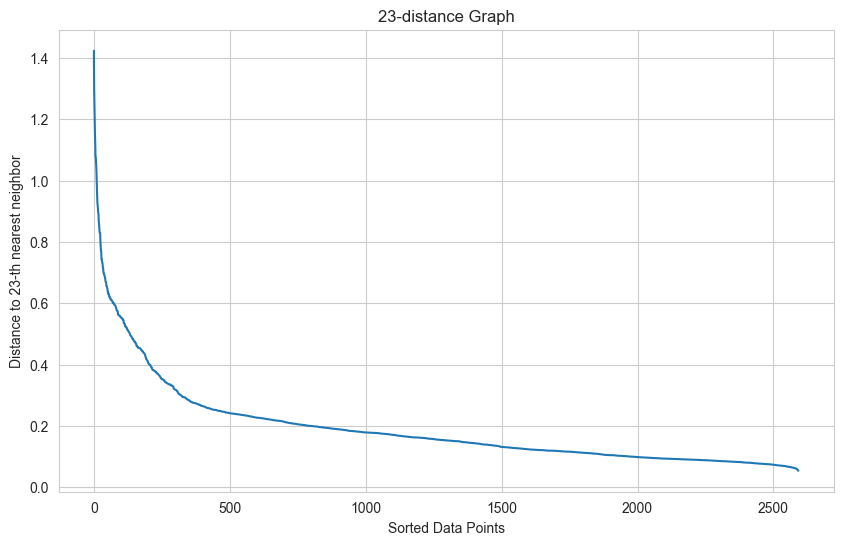

In [370]:
'''
Compute k-nearest neighbor distances and take distance 
    to k-th nearest neighbor for each point
'''
data        = bert_reduced
knn         = NearestNeighbors(n_neighbors=min_samples)
knn.fit(data)
distances, _         = knn.kneighbors(data)
kth_distances        = distances[:, -1]
sorted_kth_distances = np.sort(kth_distances, axis=0)[::-1]


'''
Plot the k-distance graph
'''
plt.figure(figsize=(10, 6))
plt.plot(sorted_kth_distances)
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.xlabel("Sorted Data Points")
plt.title(f"{min_samples}-distance Graph")
plt.grid(True)
plt.show()

<center>The value of the <code>eps</code> parameter aligns with the elbow of the k-distance graph.</center>

<center><h2>KMeans</h2></center><br>
<center><p>Optimizing the results of the KMeans algorithm for sentiment analysis also involves a combination of feature refinement and parameter tuning. In the case of the KMeans algorithm, we are mainly interested in optimizing the number of clusters <i>k</i>. Since we are not relying on labels for ground truth we will use the Silhouette Score as an internal metric for measuring the overall balance between cluster cohesion and separation and hence the quality of the clusters that are formed by the algorithm.</p></center>

In [ ]:
feature_set       = bert_reduced
range_n_clusters  = list(range(2, 16))
best_n_clusters   = 0
best_score        = -1
silhouette_scores = []

# Compute silhouette scores from range of 2 to 15 clusters
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    cluster_labels = kmeans.fit_predict(feature_set)
    
    silhouette_avg = silhouette_score(feature_set, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    if silhouette_avg > best_score:
        best_score = silhouette_avg
        best_n_clusters = n_clusters

Best number of clusters = 3 with silhouette score = 0.61.


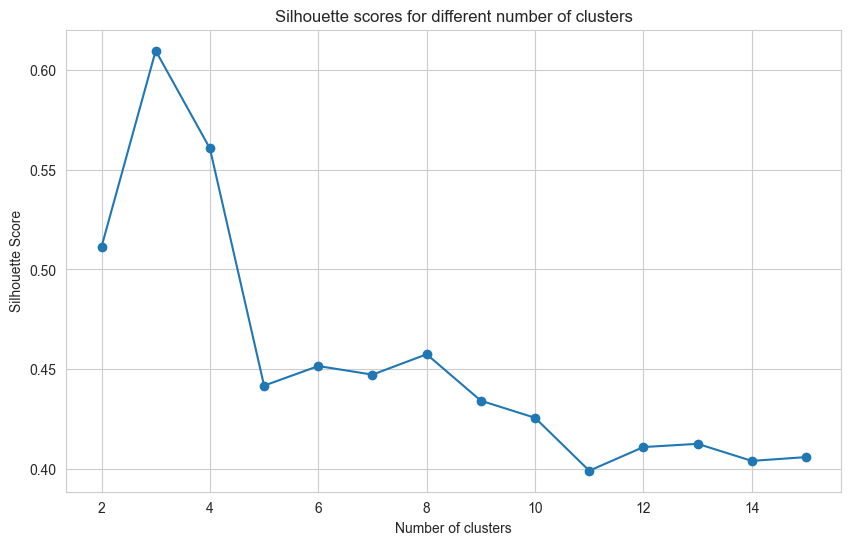

In [372]:
print(f"Best number of clusters = {best_n_clusters} with silhouette score = {best_score:.2f}.")

# Plot silhouette scores for different number of clusters
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette scores for different number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [375]:
feature_set       = bert_reduced
range_n_clusters  = list(range(2, 16))
best_n_clusters   = 0
best_score        = float('inf')  # Positive infinity because we want to minimize DB score
db_scores         = []

# Compute Davies Bouldin scores from 2 to 15 clusters
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    cluster_labels = kmeans.fit_predict(feature_set)
    
    db_score = davies_bouldin_score(feature_set, cluster_labels)
    db_scores.append(db_score)

    if db_score < best_score:
        best_score = db_score
        best_n_clusters = n_clusters

print(f"Best number of clusters = {best_n_clusters} with Davies-Bouldin score = {best_score:.2f}.")


Best number of clusters = 3 with Davies-Bouldin score = 0.58.


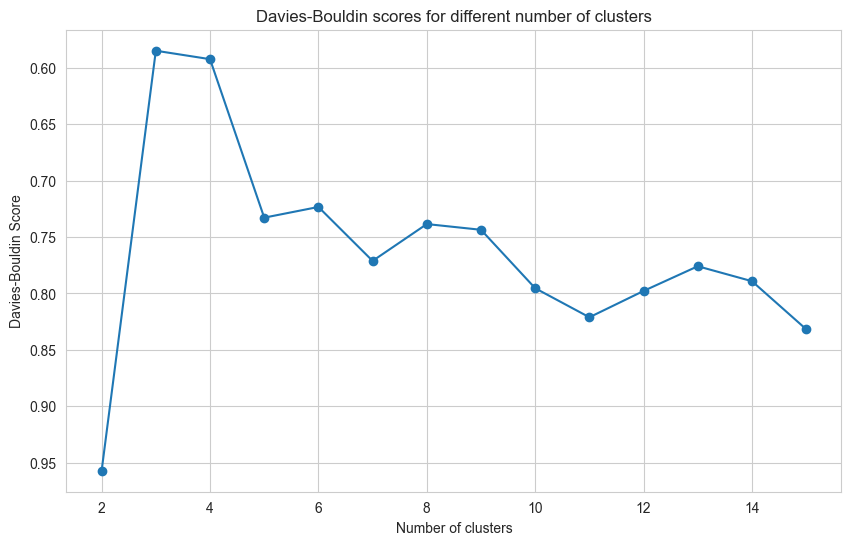

In [376]:
# Plot DB scores for different number of clusters
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, db_scores, marker='o', linestyle='-')
plt.title('Davies-Bouldin scores for different number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Score')
plt.gca().invert_yaxis()  # Lower DB scores are better so invert the y-axis for a more intuitive visualization
plt.show()

<center>Results from Silhouette and Davies-Bouldin scores suggest that we've already selected the optimal value for <i>k</i>.</center>

<center><h2>Results from Test Data</h2></center>

In [ ]:
'''
def set_classifier_results(self, clf, test_case, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_hat = clf.predict(X_test)
    self.cr[test_case] = classification_report(y_test, y_hat)
    self.cm[test_case] = confusion_matrix(y_test, y_hat)
'''

test['preprocessed_text'] = test['text'].apply(preprocess_text)
test['tokenized_text']    = test['preprocessed_text'].apply(tokenize_text)
test_tfidf_features  = tfidf_extractor.extract_features(test['tokenized_text'], False)
test_tfidf_reduced   = tfidf_extractor.reduce_features(test_tfidf_features)
test_bert_features  = [bert_extractor.extract_features(text) for text in test['tokenized_text']]
test_bert_reduced   = bert_extractor.reduce_features(test_bert_features)

In [458]:
dbscan_model_optimizer.set_distance_matrix(test_tfidf_reduced)

test_dbscan_predictions = dbscan_model_optimizer.predict(eps, min_samples)
test_dbscan_accuracy    = accuracy_score(test['label'], test_dbscan_predictions)
print("\nDBSCAN Accuracy (training): ", optimized_dbscan_accuracy)
print("DBSCAN Accuracy (test):     ", test_dbscan_accuracy)


DBSCAN Accuracy (training):  0.9101426918627072
DBSCAN Accuracy (test):      0.934409687184662


In [466]:
test_kmeans_model       = KMeansModel(test, 3)
test_kmeans_predictions = test_kmeans_model.predict(test_bert_features)
test_kmeans_accuracy    = accuracy_score(test['label'], test_kmeans_predictions)
print("\nKMeans Accuracy (training): ", kmeans_accuracy)
print("KMeans Accuracy (test):     ", test_kmeans_accuracy)


KMeans Accuracy (training):  0.5711531045121481
KMeans Accuracy (test):      0.5469223007063572


<center><h2>Feature Refinement</h2></center>
<br>
<center></center>

In [464]:
tfidf_preprocessed         = tfidf_extractor.extract_features(df['preprocessed_text'])
tfidf_preprocessed_reduced = tfidf_extractor.reduce_features(tfidf_preprocessed)
bert_preprocessed          = [bert_extractor.extract_features(text) for text in df['preprocessed_text']]
bert_preprocessed_reduced  = bert_extractor.reduce_features(bert_preprocessed)

tfidf_title         = tfidf_extractor.extract_features(df['title'])
tfidf_title_reduced = tfidf_extractor.reduce_features(tfidf_title)
bert_title          = [bert_extractor.extract_features(title) for title in df['title']]
bert_title_reduced  = bert_extractor.reduce_features(bert_title)

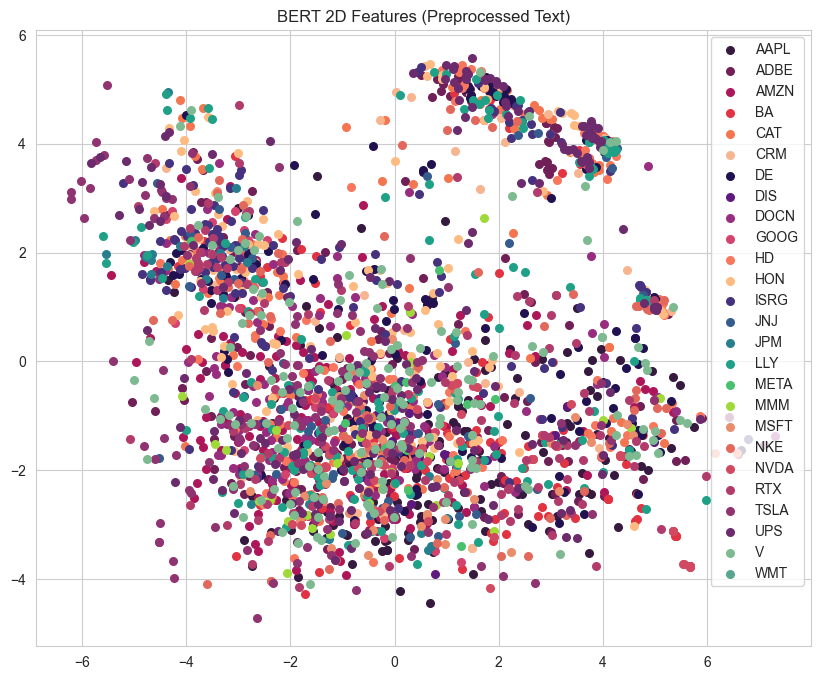

In [468]:
plot_2d(bert_preprocessed_reduced , color_list, 'BERT 2D Features (Preprocessed Text)')

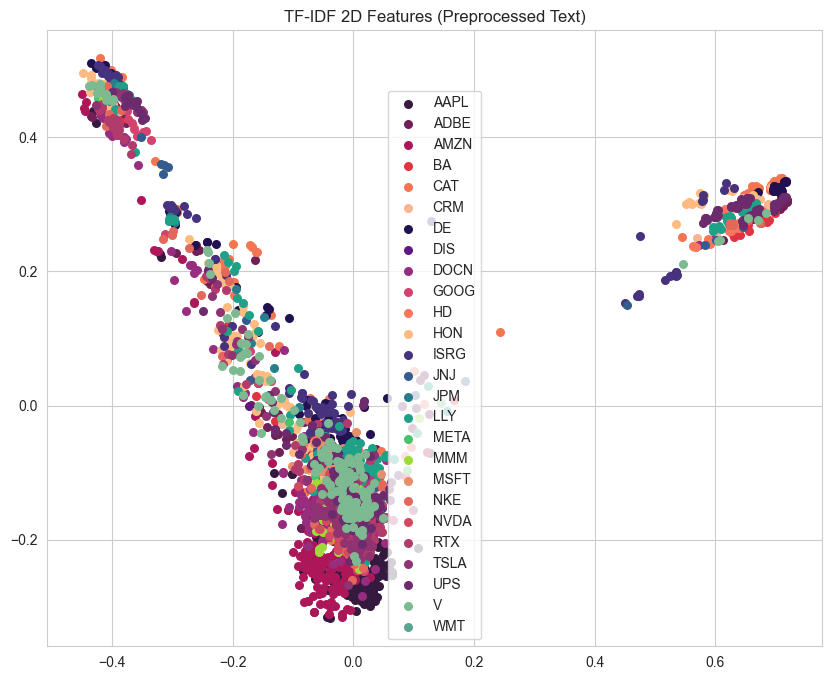

In [469]:
plot_2d(tfidf_preprocessed_reduced , color_list, 'TF-IDF 2D Features (Preprocessed Text)')

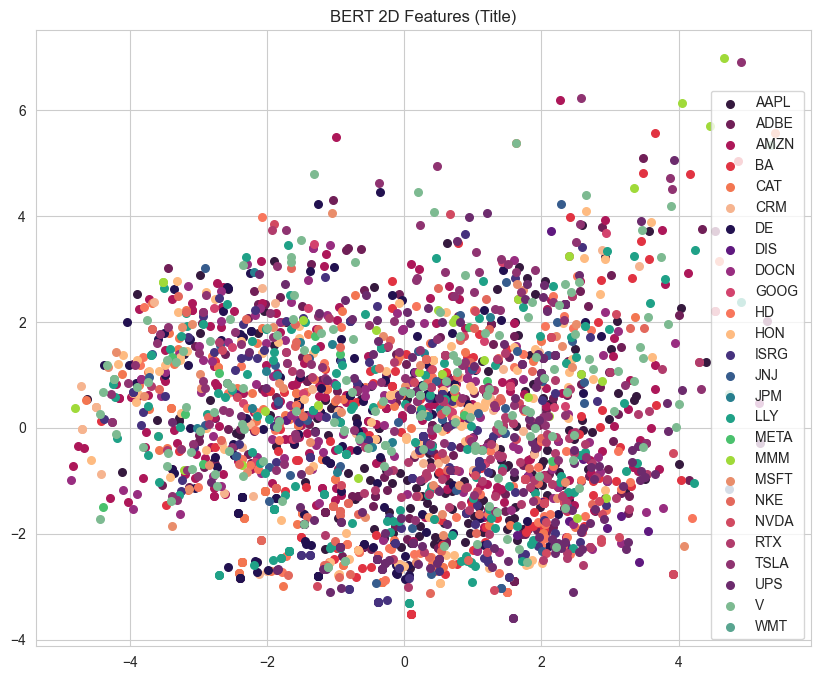

In [470]:
plot_2d(bert_title_reduced , color_list, 'BERT 2D Features (Title)')

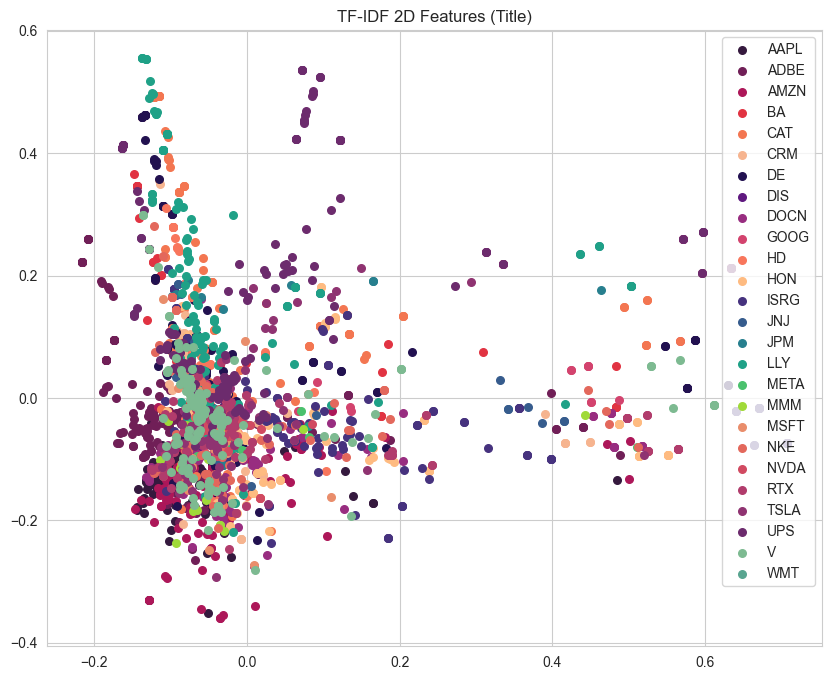

In [471]:
plot_2d(tfidf_title_reduced , color_list, 'TF-IDF 2D Features (Title)')

In [ ]:
'''
DBSCAN
'''
# preprocessed - dbscan-tfidf
eps, min_samples, _          = dbscan_model_optimizer.optimize(tfidf_preprocessed_reduced)
preprocessed_dbscan_accuracy = accuracy_score(df['label'], dbscan_model_optimizer.predict(eps, min_samples))

# preprocessed - dbscan-bert
eps, min_samples, _               = dbscan_model_optimizer.optimize(bert_preprocessed_reduced)
bert_preprocessed_dbscan_accuracy = accuracy_score(df['label'], dbscan_model_optimizer.predict(eps, min_samples))

# title - dbscan-tfidf
eps, min_samples, _   = dbscan_model_optimizer.optimize(tfidf_title_reduced)
title_dbscan_accuracy = accuracy_score(df['label'], dbscan_model_optimizer.predict(eps, min_samples))

# title - dbscan-bert
eps, min_samples, _        = dbscan_model_optimizer.optimize(bert_title_reduced)
bert_title_dbscan_accuracy = accuracy_score(df['label'], dbscan_model_optimizer.predict(eps, min_samples))

'''
KMeans
'''
# preprocessed - kmeans-bert
preprocessed_kmeans_predictions = kmeans_model.predict(bert_preprocessed, 'preprocessed_text')
preprocessed_kmeans_accuracy    = accuracy_score(df['label'], preprocessed_kmeans_predictions)

# title - kmeans-bert
title_kmeans_predictions = kmeans_model.predict(bert_title, 'title')
title_kmeans_accuracy    = accuracy_score(df['label'], title_kmeans_predictions)

# preprocessed - kmeans-tfidf
tfidf_preprocessed_kmeans_predictions = kmeans_model.predict(tfidf_preprocessed, 'preprocessed_text')
tfidf_preprocessed_kmeans_accuracy    = accuracy_score(df['label'], tfidf_preprocessed_kmeans_predictions)

# title - kmeans-tfidf
tfidf_title_kmeans_predictions = kmeans_model.predict(tfidf_title, 'title')
tfidf_title_kmeans_accuracy    = accuracy_score(df['label'], tfidf_title_kmeans_predictions)

In [481]:
print("DBSCAN Accuracy - preprocessed_text (training-tfidf): ", preprocessed_dbscan_accuracy)
print("DBSCAN Accuracy - preprocessed_text (training-bert):  ", bert_preprocessed_dbscan_accuracy)
print("DBSCAN Accuracy - title (training-tfidf):             ", title_dbscan_accuracy)
print("DBSCAN Accuracy - title (training-bert):              ", bert_title_dbscan_accuracy)
print("KMeans Accuracy - preprocessed_text (training-tfidf): ", tfidf_preprocessed_kmeans_accuracy)
print("KMeans Accuracy - preprocessed_text (training-bert):  ", preprocessed_kmeans_accuracy)
print("KMeans Accuracy - title (training-tfidf):             ", tfidf_title_kmeans_accuracy)
print("KMeans Accuracy - title (training-bert):              ", title_kmeans_accuracy)

DBSCAN Accuracy - preprocessed_text (training-tfidf):  0.9097570381797146
DBSCAN Accuracy - preprocessed_text (training-bert):   0.9101426918627072
DBSCAN Accuracy - title (training-tfidf):              0.9101426918627072
DBSCAN Accuracy - title (training-bert):               0.9101426918627072
KMeans Accuracy - preprocessed_text (training-tfidf):  0.14693405322020825
KMeans Accuracy - preprocessed_text (training-bert):   0.49055148476667954
KMeans Accuracy - title (training-tfidf):              0.6818357115310452
KMeans Accuracy - title (training-bert):               0.326263015811801


<center><h1>Conclusions</h1></center>
<br>
<center>
The strengths of DBSCAN relative to KMeans for this unsupervised learning task are apparent based on accuracy score and also upon closer inspection of the prediction sentiments. For articles where DBSCAN sentiments did not match API sentiments the analysis conducted in this notebook could not find any obvious textual basis for the discrepancies, since these mostly occurred in the context of short descriptions of Motley Fool videos that tended to lack any positive or negative sentiments. The fact that DBSCAN identified three clusters was a good result given the initial task of assigning 'neutral', 'bullish' or 'bearish' labels to articles in the dataset. DBSCAN performed better than KMeans especially in densely populated sentiment areas and was able to handle noisy outliers comparatively well.
</center>
<br>
<center>
While K-means can provide a basic approach to sentiment analysis, it's more exploratory in nature. 
Sentiments can be complex and multi-dimensional, which might not be effectively captured by K-means. 
K-means makes hard assignments of data points to clusters, meaning a data point belongs entirely to one cluster. This might not always make sense for sentiment analysis where boundaries can be blurry.
It's a simple method and might not always yield the best results for sentiment analysis compared to supervised methods or more advanced unsupervised techniques.
 </center>
 <br>
<center>There are several interesting points that arise from the feature refinement tests.  For KMeans the accuracy of sentiment predictions varies significantly depending on the feature extraction method (tf-idf vs bert) as well as the data column (title vs preprocessed vs tokenized). The lack of any significant difference in results for DBSCAN is even more surprising and suggests that further text cleaning or feature refinement is not likely to produce substantially more accurate sentiment predictions.</center>